## Overall classification: disturbed vs undisturbed

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import detrend, spectrogram
import random
import matplotlib.pyplot as plt

In [2]:
def load_and_interpolate(file):

    # Read only the measurement table
    df = pd.read_csv(
        file,
        sep="\t",
        skiprows=1,
        names=["power", "time"],
        engine="python"
    )

    # Remove footer rows
    df = df[pd.to_numeric(df["power"], errors="coerce").notna()]
    
    df["power"] = pd.to_numeric(df["power"], errors="coerce")
    df["time"] = pd.to_numeric(df["time"], errors="coerce")

    df = df.dropna()

    t = df["time"].to_numpy()
    signal = df["power"].to_numpy()

    # Average sampling interval
    dt = np.mean(np.diff(t))

    # Uniform time grid
    t_uniform = np.arange(t[0], t[-1], dt)

    # Interpolate
    signal_uniform = np.interp(
        t_uniform,
        t,
        signal
    )

    # Remove mean / drift
    signal_uniform = detrend(signal_uniform)

    return t_uniform, signal_uniform

In [3]:
def process_folder(folder):

    X = []

    for file in Path(folder).glob("*.txt"):

        t, signal = load_and_interpolate(file)

        fft_features = np.abs(np.fft.rfft(signal))[1:150]

        if len(fft_features) != 149:
            print(f"Warning: {file} produced {len(fft_features)} bins")

        X.append(fft_features)

    return np.array(X)

In [4]:
X_disturb = process_folder("Saved data/1_disturbed")
X_undisturb = process_folder("Saved data/0_undisturbed")

c:\Users\leach\miniforge3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\leach\miniforge3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


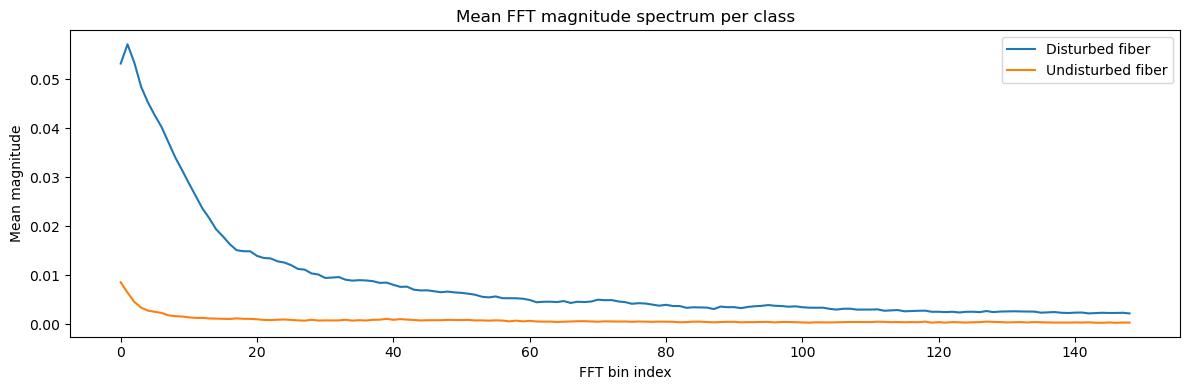

In [5]:
freqs = np.fft.rfftfreq(150, d=np.mean([np.mean(np.diff(t)) for t in []]))  # approximate

plt.figure(figsize=(12, 4))
plt.plot(np.log1p(X_disturb.mean(axis=0)), label="Disturbed fiber")
plt.plot(np.log1p(X_undisturb.mean(axis=0)), label="Undisturbed fiber")
plt.xlabel("FFT bin index")
plt.ylabel("Mean magnitude")
plt.title("Mean FFT magnitude spectrum per class")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
def plot_spectrograms(folder, label, n=3):
    all_files = list(Path(folder).glob("*.txt"))
    files = random.sample(all_files, min(n, len(all_files)))
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    
    for ax, file in zip(axes, files):
        t, signal = load_and_interpolate(file)
        dt = np.mean(np.diff(t))
        fs = 1 / dt
        
        f, tt, Sxx = spectrogram(signal, fs=fs, nperseg=64, noverlap=32)
        ax.pcolormesh(tt, f, 10*np.log10(Sxx + 1e-10), cmap="viridis")
        ax.set_xlabel("Time [s]")
        ax.set_ylabel("Frequency [Hz]")
        ax.set_title(f"{label} — {file.name}")
    
    plt.suptitle(f"Spectrograms: {label}")
    plt.tight_layout()
    plt.show()

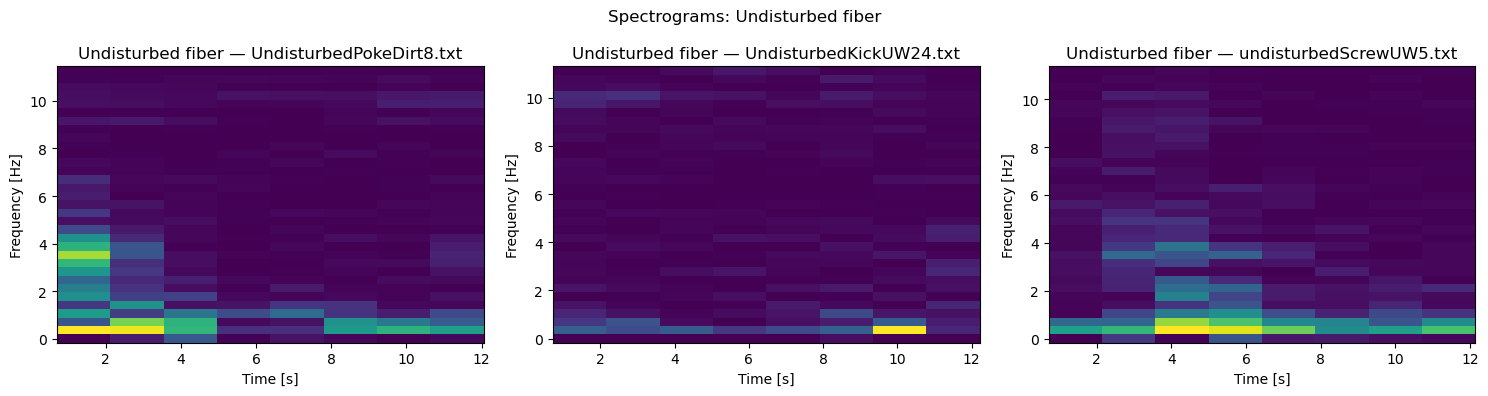

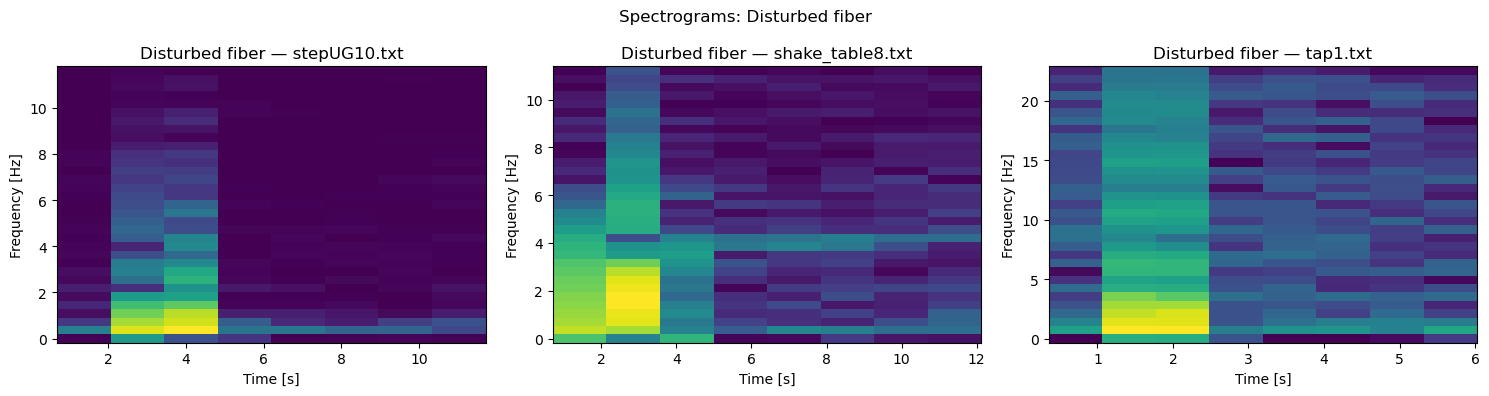

In [7]:
plot_spectrograms("Saved data/0_undisturbed", "Undisturbed fiber")
plot_spectrograms("Saved data/1_disturbed", "Disturbed fiber")

### Random Forest classification

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

In [9]:
X = np.vstack([X_disturb, X_undisturb])

y = np.concatenate([
    np.ones(len(X_disturb)),   # 1 = disturbed
    np.zeros(len(X_undisturb)) # 0 = undisturbed
])

              precision    recall  f1-score   support

   Disturbed       0.78      0.86      0.82        21
 Undisturbed       0.81      0.72      0.76        18

    accuracy                           0.79        39
   macro avg       0.80      0.79      0.79        39
weighted avg       0.80      0.79      0.79        39



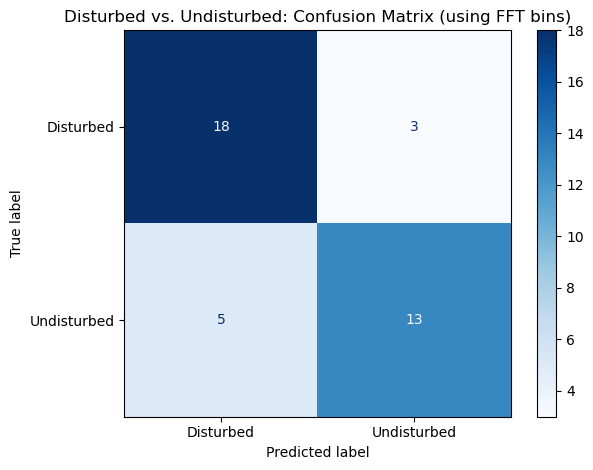

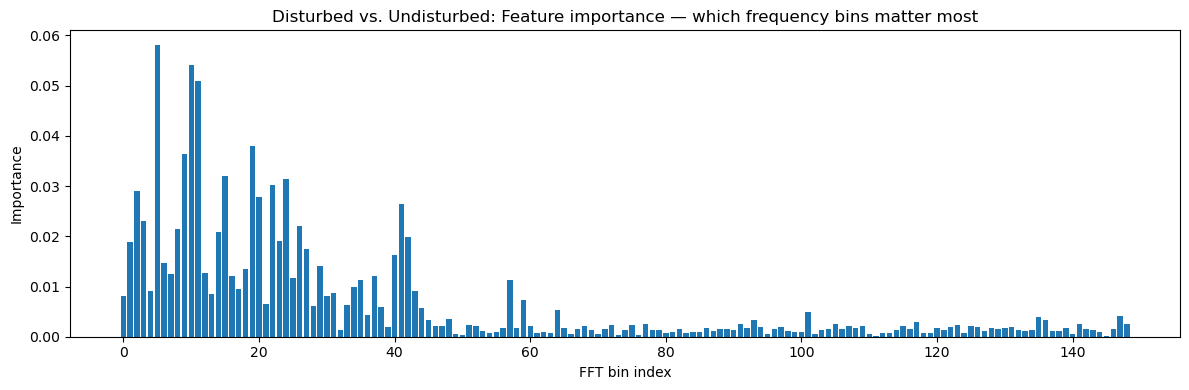

In [10]:
# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

# Train
clf = RandomForestClassifier(n_estimators=200)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Disturbed", "Undisturbed"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Disturbed", "Undisturbed"])
disp.plot(cmap="Blues")
plt.title("Disturbed vs. Undisturbed: Confusion Matrix (using FFT bins)")
plt.tight_layout()
#plt.savefig("confusion_matrix_.png", dpi=150)
plt.show()

# Feature importance
importances = clf.feature_importances_
plt.figure(figsize=(12, 4))
plt.bar(range(len(importances)), importances)
plt.xlabel("FFT bin index")
plt.ylabel("Importance")
plt.title("Disturbed vs. Undisturbed: Feature importance — which frequency bins matter most")
plt.tight_layout()
#plt.savefig("feature_importance_.png", dpi=150)
plt.show()

In [11]:
cv_scores = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
print(f"Cross-validation accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Individual folds: {cv_scores}")

Cross-validation accuracy: 0.787 ± 0.123
Individual folds: [0.82051282 0.87179487 0.69230769 0.60526316 0.94736842]


## Feature Engineering to improve model